In [ ]:
# Ensure TensorFlow is installed
# %pip install tensorflow

import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
import numpy as np
import matplotlib.pyplot as plt

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [9]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8949 - loss: 0.3811 - val_accuracy: 0.9378 - val_loss: 0.2580
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9021 - loss: 0.3685 - val_accuracy: 0.9387 - val_loss: 0.2665
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9080 - loss: 0.3567 - val_accuracy: 0.9360 - val_loss: 0.2674
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9080 - loss: 0.3509 - val_accuracy: 0.9396 - val_loss: 0.3037
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9122 - loss: 0.3305 - val_accuracy: 0.9413 - val_loss: 0.2812
313/313 - 0s - 985us/step - accuracy: 0.9408 - loss: 0.3004

Test accuracy: 0.9408000111579895 Test loss: 0.30037468671798706
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step
[7 2 1 0 4 1 4 9 5 9]


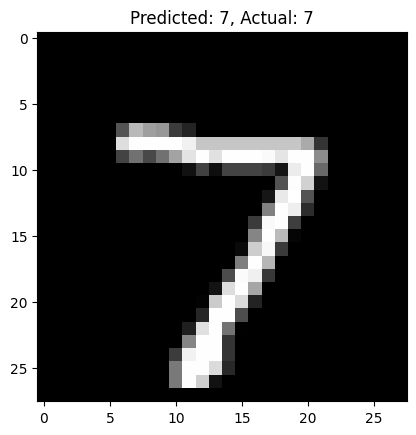

In [12]:
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc, 'Test loss:', test_loss)

# Make predictions
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
print(predicted_classes[:10])
plt.imshow(x_test[0], cmap='gray')
plt.title(f'Predicted: {predicted_classes[0]}, Actual: {y_test[0]}')
plt.show()